# Исследование объявлений о продаже квартир

### Описание проекта

Данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. 

Задача — научиться определять рыночную стоимость объектов недвижимости. Для этого провести исследовательский анализ данных и установить параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность. 

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

### Цель исследования

Определить факторы, влияющие на стоимость объектов недвижимости в Санкт-Петербурге и Ленинградской области, а также выявить особенности рынка жилья на основе данных сервиса Яндекс Недвижимость.

### Ключевые вопросы исследования

1. Какие характеристики сильнее всего влияют на стоимость квартиры?
2. Как влияет удалённость от центра города?
3. Отличается ли стоимость жилья между населёнными пунктами?
4. Как быстро обычно продаются квартиры?

### Описание данных
* airports_nearest — расстояние до ближайшего аэропорта в метрах (м)
* balcony — число балконов
* ceiling_height — высота потолков (м)
* cityCenters_nearest — расстояние до центра города (м)
* days_exposition — сколько дней было размещено объявление (от публикации до снятия)
* first_day_exposition — дата публикации
* floor — этаж
* floors_total — всего этажей в доме
* is_apartment — апартаменты (булев тип)
* kitchen_area — площадь кухни в квадратных метрах (м²)
* last_price — цена на момент снятия с публикации
* living_area — жилая площадь в квадратных метрах (м²)
* locality_name — название населённого пункта
* open_plan — свободная планировка (булев тип)
* parks_around3000 — число парков в радиусе 3 км
* parks_nearest — расстояние до ближайшего парка (м)
* ponds_around3000 — число водоёмов в радиусе 3 км
* ponds_nearest — расстояние до ближайшего водоёма (м)
* rooms — число комнат
* studio — квартира-студия (булев тип)
* total_area — общая площадь квартиры в квадратных метрах (м²)
* total_images — число фотографий квартиры в объявлении



## Общая информация

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.options.display.max_columns = None
pd.options.display.float_format = '{:,.0f}'.format

In [2]:
data = pd.read_csv('real_estate_data.csv', sep='\t')
data.head()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,"13,000,000",108,2019-03-07T00:00:00,3,3,16,51,8,NaN,False,False,25,NaN,Санкт-Петербург,"18,863","16,028",1,482,2,755,NaN
1,7,"3,350,000",40,2018-12-04T00:00:00,1,NaN,11,19,1,NaN,False,False,11,2,посёлок Шушары,"12,817","18,603",0,NaN,0,NaN,81
2,10,"5,196,000",56,2015-08-20T00:00:00,2,NaN,5,34,4,NaN,False,False,8,0,Санкт-Петербург,"21,741","13,933",1,90,2,574,558
3,0,"64,900,000",159,2015-07-24T00:00:00,3,NaN,14,NaN,9,NaN,False,False,NaN,0,Санкт-Петербург,"28,098","6,800",2,84,3,234,424
4,2,"10,000,000",100,2018-06-19T00:00:00,2,3,14,32,13,NaN,False,False,41,NaN,Санкт-Петербург,"31,856","8,098",2,112,1,48,121


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  str    
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  str    
 15  airports_nearest      18157 no

In [4]:
data.describe()

,total_images,last_price,total_area,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
count,"23,699","23,699","23,699","23,699","14,504","23,613","21,796","23,699","21,421","12,180","18,157","18,180","18,181","8,079","18,181","9,110","20,518"
mean,10,"6,541,549",60,2,3,11,34,6,11,1,"28,794","14,191",1,491,1,518,181
std,6,"10,887,013",36,1,1,7,22,5,6,1,"12,631","8,608",1,342,1,278,220
min,0,"12,190",12,0,1,1,2,1,1,0,0,181,0,1,0,13,1
25%,6,"3,400,000",40,1,3,5,19,2,7,0,"18,585","9,238",0,288,0,294,45
50%,9,"4,650,000",52,2,3,9,30,4,9,1,"26,726","13,098",0,455,1,502,95
75%,14,"6,800,000",70,3,3,16,42,8,12,2,"37,273","16,293",1,612,1,729,232
max,50,"763,000,000",900,19,100,60,410,33,112,5,"84,869","65,968",3,"3,190",3,"1,344","1,580"


## Предобработка данных

### Пропущенные значения в столбцах

In [5]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Пропуски в balcony могли возникнуть из-за того, что продавцы не указывали информацию о балконах. В большинстве таких случаев можно предположить отсутствие балкона.

Аналогично и с пропусками в is_apartment. 

In [6]:
data['balcony'] = data['balcony'].fillna(0)

In [7]:
data['is_apartment'] = data['is_apartment'].fillna(False)

In [8]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment                0
studio                      0
open_plan                   0
kitchen_area             2278
balcony                     0
locality_name              49
airports_nearest         5542
cityCenters_nearest      5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

Пропуски в parks_nearest, ponds_nearest и других географических признаках могли возникнуть из-за отсутствия объектов поблизости либо из-за неполноты картографических данных. Мы не можем восстановить их с достаточной точностью.

### Типы данных

In [9]:
data.dtypes

total_images              int64
last_price              float64
total_area              float64
first_day_exposition        str
rooms                     int64
ceiling_height          float64
floors_total            float64
living_area             float64
floor                     int64
is_apartment             object
studio                     bool
open_plan                  bool
kitchen_area            float64
balcony                 float64
locality_name               str
airports_nearest        float64
cityCenters_nearest     float64
parks_around3000        float64
parks_nearest           float64
ponds_around3000        float64
ponds_nearest           float64
days_exposition         float64
dtype: object

In [10]:
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'])
data['first_day_exposition']

0       2019-03-07
1       2018-12-04
2       2015-08-20
3       2015-07-24
4       2018-06-19
           ...    
23694   2017-03-21
23695   2018-01-15
23696   2018-02-11
23697   2017-03-28
23698   2017-07-21
Name: first_day_exposition, Length: 23699, dtype: datetime64[us]

Столбец first_day_exposition был преобразован в тип datetime для возможности извлечения дня недели, месяца и года публикации объявления.

In [11]:
data['balcony'] = data['balcony'].astype('int')
data['balcony'] 

0        0
1        2
2        0
3        0
4        0
        ..
23694    0
23695    0
23696    0
23697    2
23698    0
Name: balcony, Length: 23699, dtype: int64

In [12]:
data['floors_total'] = data['floors_total'].astype('Int64')
data['floors_total'] 

0        16
1        11
2         5
3        14
4        14
         ..
23694     5
23695     5
23696     3
23697    17
23698     5
Name: floors_total, Length: 23699, dtype: Int64

In [13]:
data['days_exposition'] = data['days_exposition'].round().astype('Int64')
data['days_exposition']

0        <NA>
1          81
2         558
3         424
4         121
         ... 
23694    <NA>
23695      45
23696    <NA>
23697     602
23698    <NA>
Name: days_exposition, Length: 23699, dtype: Int64

### Обработка дубликатов

In [14]:
data.duplicated().sum()

np.int64(0)

Явных дубликатов нет. 

In [15]:
print(len(data['locality_name'].unique()))
data['locality_name'].unique()

365


<StringArray>
[          'Санкт-Петербург',            'посёлок Шушары',
 'городской посёлок Янино-1',         'посёлок Парголово',
            'посёлок Мурино',                 'Ломоносов',
                 'Сертолово',                  'Петергоф',
                    'Пушкин',           'деревня Кудрово',
 ...
   'деревня Большое Рейзино',   'деревня Малая Романовка',
       'поселок Дружноселье',            'поселок Пчевжа',
       'поселок Володарское',            'деревня Нижняя',
 'коттеджный посёлок Лесное',         'деревня Тихковицы',
    'деревня Борисова Грива',      'посёлок Дзержинского']
Length: 365, dtype: str

Избавимся от неявных дубликатов в названии населенного пункта. 

In [16]:
to_replace = ['поселок городского типа ', 'коттеджный поселок ', 'садовое товарищество ', 'садоводческое некоммерческое товарищество ', 
              'городской поселок ', 'при железнодорожной станции ', 'станции ', 'поселок ', 'деревня ', 'село ']

data['locality_name_clean'] = (
    data['locality_name']
    .str.replace('ё', 'е')
    .replace(to_replace, '', regex=True)
)

In [17]:
print(len(data['locality_name_clean'].unique()))
data['locality_name_clean'].unique()

306


<StringArray>
['Санкт-Петербург',          'Шушары',         'Янино-1',       'Парголово',
          'Мурино',       'Ломоносов',       'Сертолово',        'Петергоф',
          'Пушкин',         'Кудрово',
 ...
       'Лупполово', 'Большое Рейзино', 'Малая Романовка',     'Дружноселье',
          'Пчевжа',     'Володарское',          'Нижняя',       'Тихковицы',
  'Борисова Грива',    'Дзержинского']
Length: 306, dtype: str

##  Создание новых признаков

- цена одного квадратного метра;
- день недели публикации объявления (0 — понедельник, 1 — вторник и так далее);
- месяц публикации объявления;
- год публикации объявления;
- тип этажа квартиры (значения — «первый», «последний», «другой»);
- расстояние до центра города в километрах.

In [18]:
data['price_m2'] = round(data['last_price'] / data['total_area'], 2)
data['price_m2']

0       120,370
1        82,921
2        92,786
3       408,176
4       100,000
          ...  
23694    72,491
23695    52,542
23696    44,092
23697   149,511
23698    41,796
Name: price_m2, Length: 23699, dtype: float64

In [19]:
data['weekday_exposition'] = data['first_day_exposition'].dt.weekday
data['weekday_exposition']

0        3
1        1
2        3
3        4
4        1
        ..
23694    1
23695    0
23696    6
23697    1
23698    4
Name: weekday_exposition, Length: 23699, dtype: int32

In [20]:
data['month_exposition'] = data['first_day_exposition'].dt.month
data['month_exposition']

0         3
1        12
2         8
3         7
4         6
         ..
23694     3
23695     1
23696     2
23697     3
23698     7
Name: month_exposition, Length: 23699, dtype: int32

In [21]:
data['year_exposition'] = data['first_day_exposition'].dt.year
data['year_exposition']

0        2019
1        2018
2        2015
3        2015
4        2018
         ... 
23694    2017
23695    2018
23696    2018
23697    2017
23698    2017
Name: year_exposition, Length: 23699, dtype: int32

In [22]:
data['floor_type'] = 'другой' 

data.loc[data['floor'] == data['floors_total'], 'floor_type'] = 'последний'
data.loc[data['floor'] == 1, 'floor_type'] = 'первый'

In [23]:
data['cityCenters_nearest_km'] = round(data['cityCenters_nearest'] / 1000)
data['cityCenters_nearest_km']

0        16
1        19
2        14
3         7
4         8
         ..
23694     4
23695   NaN
23696   NaN
23697    10
23698   NaN
Name: cityCenters_nearest_km, Length: 23699, dtype: float64

## Исследовательский анализ данных

Список параметров для анализа:
- общая площадь;
- жилая площадь;
- площадь кухни;
- цена объекта;
- количество комнат;
- высота потолков;
- тип этажа квартиры («первый», «последний», «другой»);
- общее количество этажей в доме;
- расстояние до центра города в метрах;
- расстояние до ближайшего парка. 

In [24]:
def distribution_graphs(data_col, title, binrange=None, number_of_bins=30, log_func=False):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))

    sns.histplot(data_col, bins=number_of_bins, ax=ax[0], binrange=binrange)
    ax[0].grid(True)
    ax[0].set_xlabel('')
    ax[0].set_ylabel('')

    if log_func==True:
        ax[0].set_yscale('log')

    sns.boxplot(y=data_col, ax=ax[1], widths=0.4, medianprops={'color': 'red', 'linewidth': 1.5},
    flierprops={'marker': 'D', 'markerfacecolor': 'white', 'markeredgecolor':'black','linewidth': 2})

    ax[1].grid(True)
    ax[1].set_ylabel('')

    plt.suptitle(f'Гистограмма и диаграмма размаха параметра: {title}', fontsize=14)

    plt.tight_layout()

In [25]:
real_estate_data = data.copy()

#### Общая площадь

In [26]:
data['total_area'].describe()

count   23,699
mean        60
std         36
min         12
25%         40
50%         52
75%         70
max        900
Name: total_area, dtype: float64

Проверим данные с некорректно рассчитанной общей площадью.

In [27]:
data.query('(kitchen_area + living_area) > total_area')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,locality_name_clean,price_m2,weekday_exposition,month_exposition,year_exposition,floor_type,cityCenters_nearest_km
184,7,"2,600,000",30,2018-02-14,1,3,9,26,5,False,False,False,6,0,Санкт-Петербург,"13,952","15,031",0,NaN,1,824,12,Санкт-Петербург,"86,093",2,2,2018,другой,15
545,9,"4,700,000",24,2018-12-28,1,NaN,18,20,9,False,False,False,5,0,Санкт-Петербург,"9,731","11,849",0,NaN,0,NaN,108,Санкт-Петербург,"197,479",4,12,2018,другой,12
551,8,"3,100,000",32,2018-03-08,1,3,19,31,2,False,False,False,9,2,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,70,Мурино,"98,132",3,3,2018,другой,NaN
601,12,"5,600,000",54,2017-04-18,2,2,12,48,5,False,False,False,7,2,Санкт-Петербург,"50,477","13,252",2,220,1,"1,250",167,Санкт-Петербург,"104,283",1,4,2017,другой,13
696,1,"3,364,930",35,2014-11-27,1,3,25,23,25,False,False,False,23,2,Санкт-Петербург,"43,396","12,153",0,NaN,0,NaN,574,Санкт-Петербург,"97,000",3,11,2014,последний,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21824,20,"2,450,000",44,2019-02-12,2,27,2,38,2,False,False,False,9,2,городской поселок Большая Ижора,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,Большая Ижора,"55,682",1,2,2019,последний,NaN
21868,12,"2,600,000",34,2018-09-26,1,2,9,31,6,False,False,False,8,2,Сосновый Бор,NaN,NaN,NaN,NaN,NaN,NaN,107,Сосновый Бор,"75,802",2,9,2018,другой,NaN
21915,14,"11,990,000",91,2016-05-16,2,NaN,16,62,12,False,False,False,32,0,Санкт-Петербург,"10,934","12,551",0,NaN,0,NaN,93,Санкт-Петербург,"131,182",0,5,2016,другой,13
21956,0,"5,200,000",46,2018-07-20,2,NaN,5,44,5,False,False,False,8,1,Санкт-Петербург,"14,103","15,182",1,488,0,NaN,7,Санкт-Петербург,"113,043",4,7,2018,последний,15


Есть некорректные данные в `total_area`. Пересчитаем корректные значения

In [28]:
mask = data['kitchen_area'] + data['living_area'] > data['total_area']

data.loc[mask, 'total_area'] = data.loc[mask, 'kitchen_area'] + data.loc[mask, 'living_area']

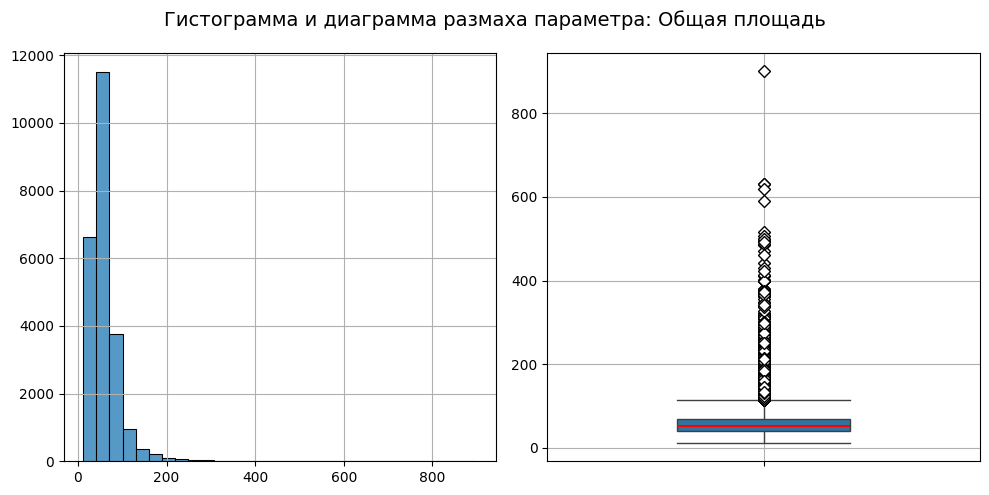

In [29]:
distribution_graphs(data['total_area'], 'Общая площадь')

Распределение имеет длинный правый хвост, что говорит о наличии небольшого числа очень крупных объектов. Чтобы выбросы не исказили выводы дальнейшего исследования, удалим аномальные значения с помощью межквартильного размаха IQR.

In [30]:
def iqr_outliers(col):

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    min_value = Q1 - 1.5 * IQR
    max_value = Q3 + 1.5 * IQR

    clean_data = data[(data[col] >= min_value) & (data[col] <= max_value)]

    print(f'После удаления выбросов осталось {round(clean_data[col].notna().sum() / real_estate_data[col].notna().sum() * 100, 2)}% данных')

    return clean_data

In [31]:
data = iqr_outliers('total_area')

После удаления выбросов осталось 94.76% данных


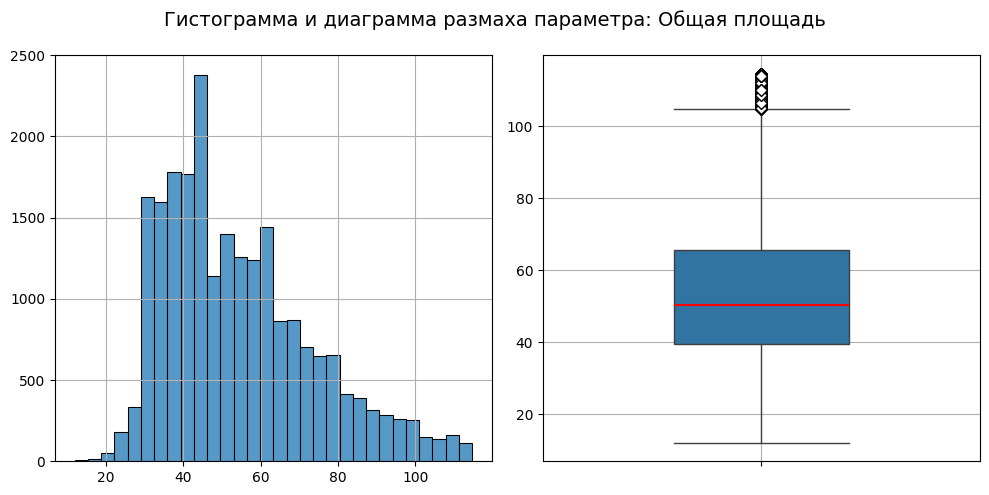

In [32]:
distribution_graphs(data['total_area'], 'Общая площадь')

Большинство квартир имеют площадь до 100 м2, а преобладающее большинство - от 40 до 65 м2. 

#### Жилая площадь

In [33]:
data['living_area'].describe()

count   20,684
mean        31
std         14
min          2
25%         18
50%         30
75%         40
max        101
Name: living_area, dtype: float64

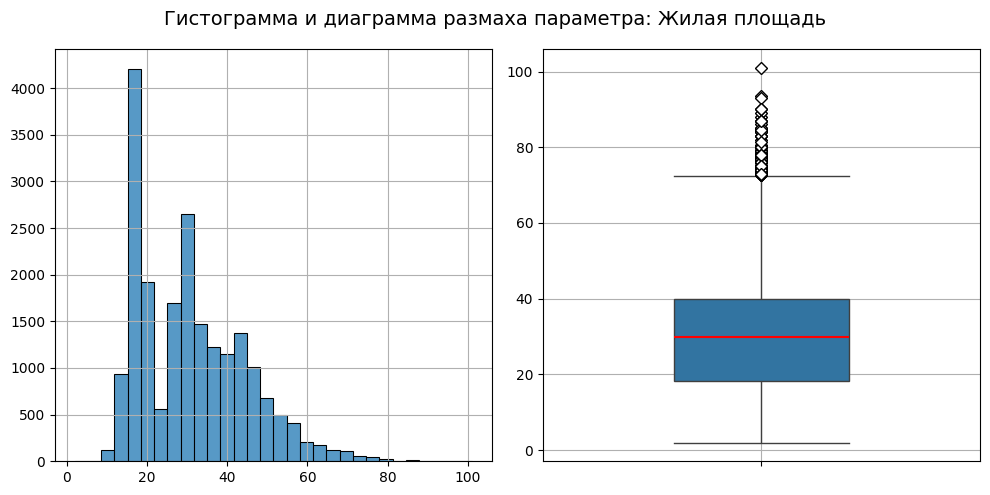

In [34]:
distribution_graphs(data['living_area'], 'Жилая площадь')

Большинство квартир имеют жилую площадь от 18 до 40 м2, есть единичные значения с жилой площадью до 100м2. 

#### Площадь кухни

In [35]:
data['kitchen_area'].describe()

count   20,293
mean        10
std          4
min          1
25%          7
50%          9
75%         11
max         56
Name: kitchen_area, dtype: float64

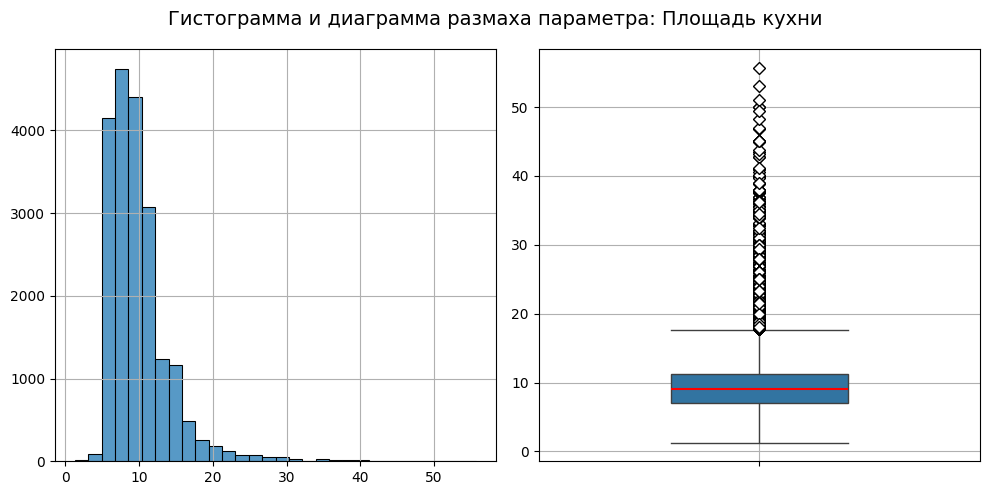

In [36]:
distribution_graphs(data['kitchen_area'], 'Площадь кухни')

Большинство квартир имеют площадь кухни от 7 до 11 м2, также есть значения с площадью до 56 м2, но не будем считать их аномальными. 

#### Цена объекта

In [37]:
data['last_price'].describe()

count       22,458
mean     5,307,025
std      3,395,019
min         12,190
25%      3,358,500
50%      4,500,000
75%      6,300,000
max     82,000,000
Name: last_price, dtype: float64

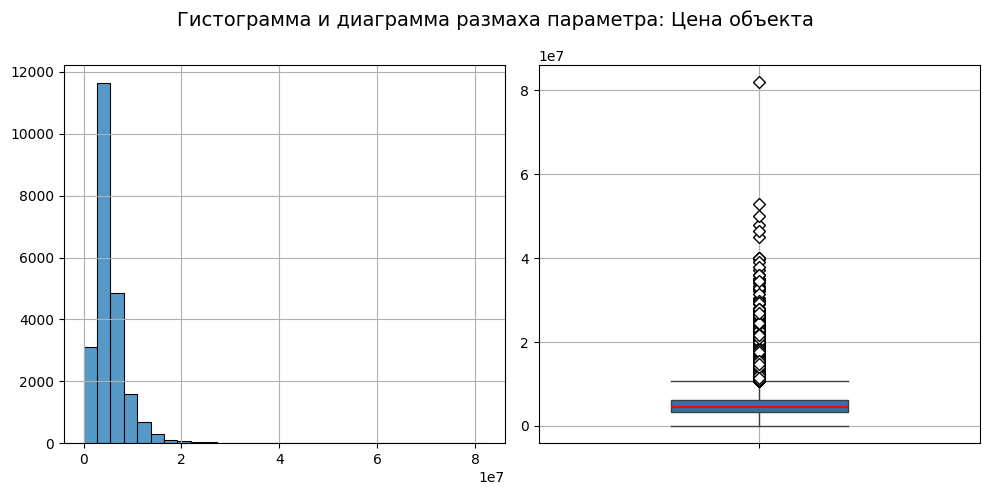

In [38]:
distribution_graphs(data['last_price'], 'Цена объекта')

Основная часть объявлений сосредоточена в диапазоне до 10 млн рублей. Более дорогие квартиры встречаются значительно реже. Наблюдаем много аномалий, избавимся от них с помощью IQR

In [39]:
data = iqr_outliers('last_price')

После удаления выбросов осталось 89.11% данных


In [40]:
data[data['last_price'] < 400000]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,locality_name_clean,price_m2,weekday_exposition,month_exposition,year_exposition,floor_type,cityCenters_nearest_km
8793,7,"12,190",109,2019-03-20,2,3,25,32,25,False,False,False,40,0,Санкт-Петербург,"36,421","9,176",1,805,0,NaN,8,Санкт-Петербург,112,2,3,2019,последний,9


Стоимость объекта 12 190 рублей выглядит аномальной для рынка продажи недвижимости и, вероятно, цена квартиры была записана в тысячах руб.Cкорректируем значение

In [41]:
data.loc[data['last_price']==12190, 'last_price'] = 12190000

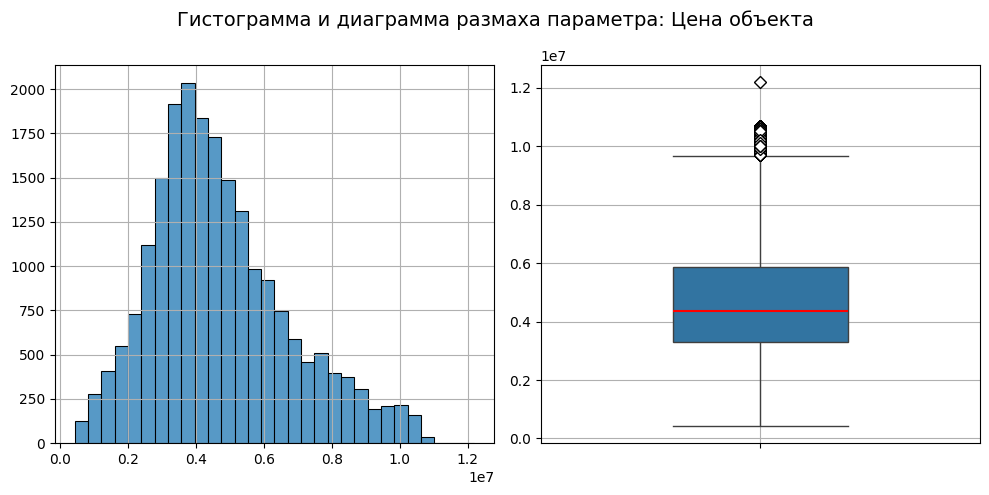

In [42]:
distribution_graphs(data['last_price'], 'Цена объекта')

После удаления аномальных значений, большинство квартир стоят от 3,3 до 5,85 млн. р. Максимальная стоимость квартиры - 12,19 млн. р.

#### Количество комнат

In [43]:
data['rooms'].describe()

count   21,118
mean         2
std          1
min          0
25%          1
50%          2
75%          3
max          6
Name: rooms, dtype: float64

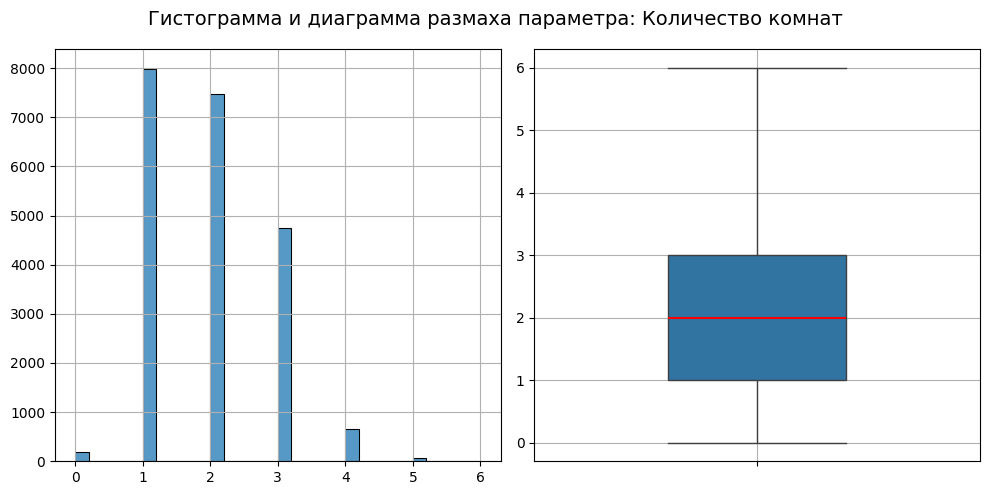

In [44]:
distribution_graphs(data['rooms'], 'Количество комнат')

Аномально больших значений количества комнат нет. Но встречаются квартиры с количеством комнат = 0, что невозможно. Посмотрим на эти такие квартиры внимательнее. 

In [45]:
data.query('rooms == 0').describe()

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,kitchen_area,balcony,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,price_m2,weekday_exposition,month_exposition,year_exposition,cityCenters_nearest_km
count,195,195,195,195,195,80,192,182,195,0,195,116,116,116,28,116,67,181,195,195,195,195,116
mean,8,"2,924,265",27,2018-01-16 03:19:23.076923,0,3,17,19,9,NaN,1,"24,489","13,517",0,589,1,523,107,"107,795",3,7,"2,017",13
min,0,"945,750",16,2015-02-11 00:00:00,0,2,3,2,1,NaN,0,"6,989","1,261",0,38,0,72,3,"34,375",0,1,"2,015",1
25%,4,"2,300,000",24,2017-09-27 00:00:00,0,3,12,16,3,NaN,0,"14,247","11,663",0,393,0,342,27,"91,064",1,4,"2,017",12
50%,7,"2,700,000",26,2017-12-08 00:00:00,0,3,17,18,7,NaN,1,"21,131","13,672",0,532,1,527,49,"105,098",3,8,"2,017",14
75%,11,"3,362,500",28,2018-07-16 12:00:00,0,3,23,20,13,NaN,2,"34,201","16,482",0,776,1,687,116,"125,000",4,10,"2,018",16
max,21,"8,200,000",74,2019-04-26 00:00:00,0,27,35,68,26,NaN,2,"55,551","29,846",2,"1,199",3,"1,159",931,"231,960",6,12,"2,019",30
std,5,"1,043,088",7,NaN,0,3,7,6,6,NaN,1,"12,492","4,974",1,307,1,278,156,"27,171",2,4,1,5


Ни у одной такой квартиры не указана площадь кухни. Возможно, это квартиры-студии или с открытой планировкой. 

In [46]:
data.query('rooms == 0')[['studio', 'open_plan', 'total_area']]

,studio,open_plan,total_area
144,True,False,27
349,False,True,25
440,True,False,27
508,False,True,34
608,True,False,25
...,...,...,...
23210,True,False,26
23442,False,True,28
23554,True,False,26
23592,False,True,29


Все объекты с нулевым количеством комнат относятся к студиям или квартирам со свободной планировкой, поэтому такие значения не являются ошибкой.

In [47]:
data.loc[data['rooms']==0, 'rooms'] = 1

In [48]:
data.query('rooms > 1 and (studio or open_plan)')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,locality_name_clean,price_m2,weekday_exposition,month_exposition,year_exposition,floor_type,cityCenters_nearest_km
8861,13,"5,500,000",64,2015-11-13,3,3,5,48,2,False,False,True,NaN,0,Санкт-Петербург,"20,040","2,621",2,205,2,204,229,Санкт-Петербург,"85,271",4,11,2015,другой,3
12760,0,"3,350,000",51,2015-01-22,2,2,12,30,10,False,False,True,NaN,2,Коммунар,NaN,NaN,NaN,NaN,NaN,NaN,521,Коммунар,"65,686",3,1,2015,другой,NaN
14017,13,"3,990,000",59,2016-03-29,3,2,9,38,3,False,False,True,NaN,1,Колпино,"27,820","33,606",0,NaN,1,705,81,Колпино,"67,627",1,3,2016,другой,34


Для объектов со свободной планировкой количество комнат приведем к 1, поскольку наличие нескольких изолированных комнат противоречит определению свободной планировки.

In [49]:
idx = data.query('rooms > 1 and (studio or open_plan)').index
data.loc[idx, 'open_plan'] = False

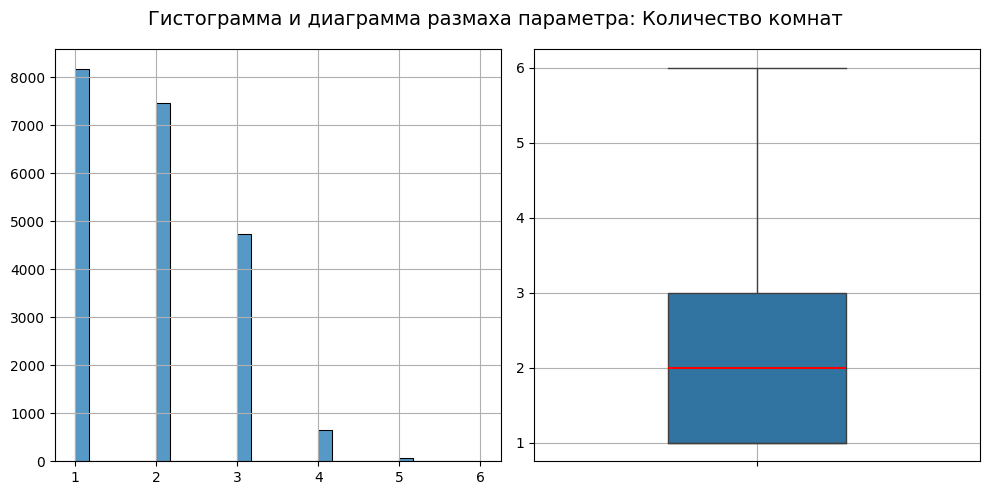

In [50]:
distribution_graphs(data['rooms'], 'Количество комнат')

Большинство квартир имеет до 3 комнат, но также встречаются и 6-ти комнатные квартиры. 

#### Высота потолков

In [51]:
data['ceiling_height'].describe()

count   12,746
mean         3
std          1
min          1
25%          2
50%          3
75%          3
max         32
Name: ceiling_height, dtype: float64

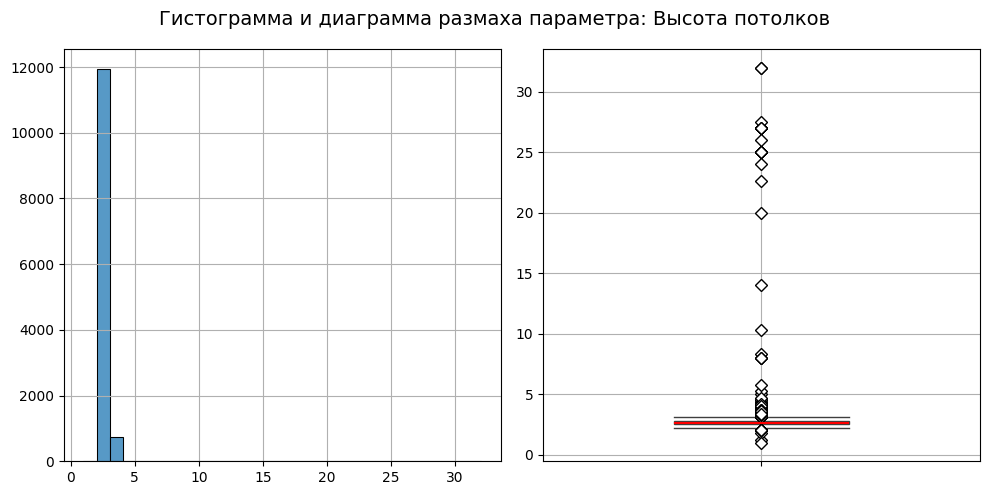

In [52]:
distribution_graphs(data['ceiling_height'], 'Высота потолков', log_func=False)

Потолки `ceiling_height` высотой в 1 и 100 метров являются аномалией в данных, так как жилой квартиры с таким потолком скорее всего не существует на рынке недвижимости. 

Аномально большие значение могут быть вызваны ошибкой при заполнении (не 25 м, а 2,5 м).

In [53]:
data.loc[data['ceiling_height'] >= 20, 'ceiling_height'] = data.loc[data['ceiling_height'] >= 25, 'ceiling_height'] / 10

Встречаются и аномально малые значения менее 2х метров. 

In [54]:
data[data['ceiling_height'] < 2]['ceiling_height']

5712    1
16934   2
22590   1
Name: ceiling_height, dtype: float64

Всего 3 значения, поэтому можем удалить такие данные

In [55]:
data = data[~(data['ceiling_height'] < 2)]

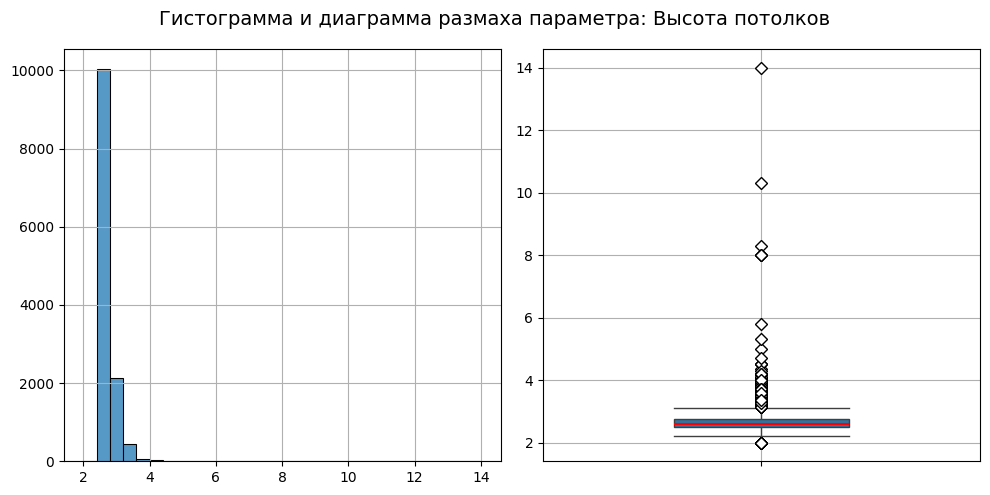

In [56]:
distribution_graphs(data['ceiling_height'], 'Высота потолков', log_func=False)

In [57]:
data['ceiling_height'].describe()

count   12,740
mean         3
std          0
min          2
25%          2
50%          3
75%          3
max         14
Name: ceiling_height, dtype: float64

Высота потолков у большинства квартир лежит в диапазоне от 2 до 3 м. Максимальное значение - 14 м. 

#### Тип этажа квартиры

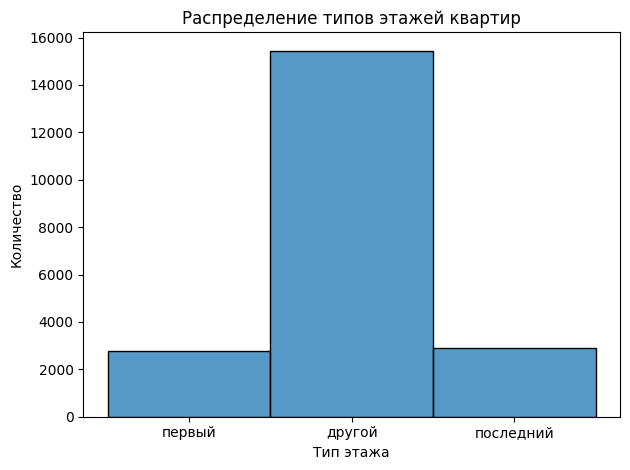

In [58]:
sns.histplot(data['floor_type'])

plt.title('Распределение типов этажей квартир')
plt.xlabel('Тип этажа')
plt.ylabel('Количество')

plt.tight_layout()

Большинство квартир расположены не на первом и не на последнем этаже. 

#### Общее количество этажей в доме

In [59]:
data['floors_total'].describe()

count   21,043
mean        11
std          7
min          1
25%          5
50%          9
75%         16
max         60
Name: floors_total, dtype: Float64

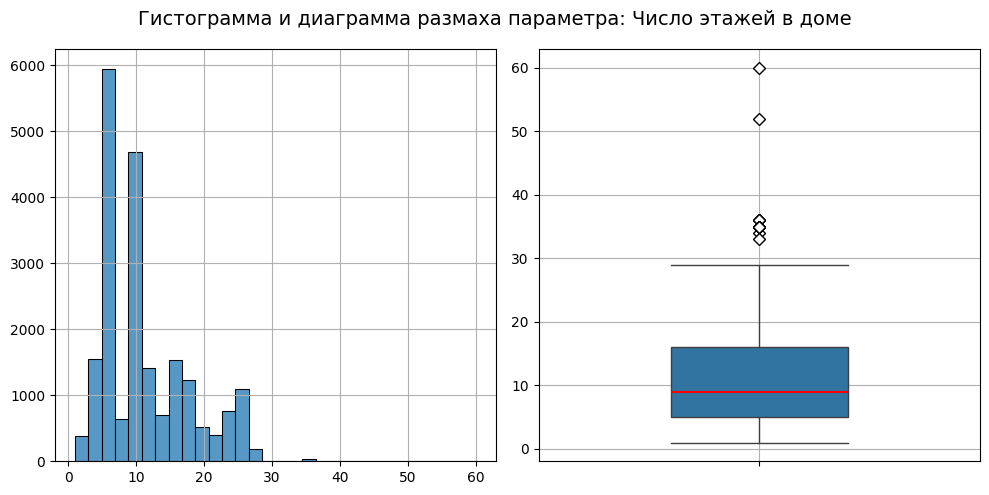

In [60]:
distribution_graphs(data['floors_total'], 'Число этажей в доме', log_func=False)

Большинство квартир расположено в домах высотой от 5 до 16 этажей.

#### Расстояние до центра города в метрах

In [61]:
data['cityCenters_nearest'].describe()

count   15,657
mean    15,129
std      8,501
min        208
25%     10,787
50%     13,736
75%     16,788
max     65,968
Name: cityCenters_nearest, dtype: float64

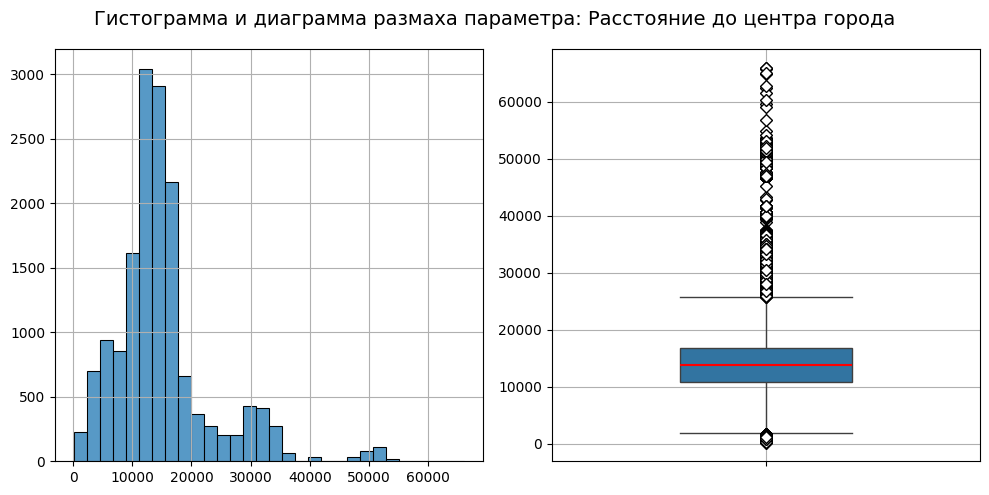

In [62]:
distribution_graphs(data['cityCenters_nearest'], 'Расстояние до центра города')

Встречаются как и квартиры, расположенные в центре города, так и в отдалении от него (65 км). 

#### Расстояние до ближайшего парка

In [63]:
data['parks_nearest'].describe()

count   6,450
mean      488
std       324
min         1
25%       290
50%       456
75%       613
max     3,190
Name: parks_nearest, dtype: float64

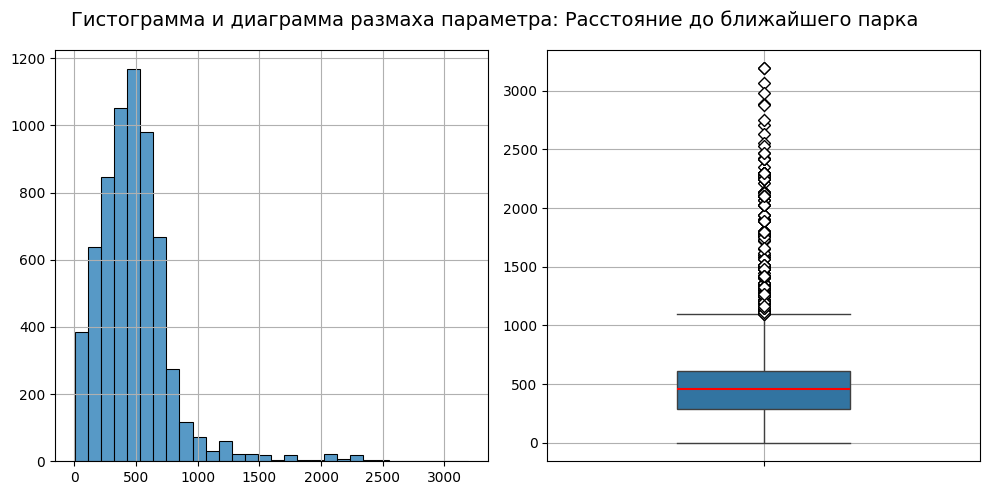

In [64]:
distribution_graphs(data['parks_nearest'], 'Расстояние до ближайшего парка')

Квартира не может находится прямо в парке. Ограничим минимальное значение 10 метрами.

In [65]:
data[data['parks_nearest'] < 10]

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,locality_name_clean,price_m2,weekday_exposition,month_exposition,year_exposition,floor_type,cityCenters_nearest_km
2527,8,"4,690,000",60,2016-03-05,2,2,5,28,2,False,False,False,8,0,Кронштадт,"69,775","51,500",3,9,3,345,146,Кронштадт,"77,778",5,3,2016,другой,52
9344,12,"3,000,000",28,2017-07-25,1,2,9,17,1,False,False,False,6,0,Санкт-Петербург,"12,051","11,665",1,7,1,780,440,Санкт-Петербург,"106,762",1,7,2017,первый,12
11949,7,"4,500,000",44,2017-11-24,2,3,9,30,7,False,False,False,7,0,Санкт-Петербург,"11,806","12,292",1,3,1,508,82,Санкт-Петербург,"102,273",4,11,2017,другой,12
14624,8,"3,770,000",45,2019-03-20,2,NaN,9,28,2,False,False,False,7,0,Санкт-Петербург,"43,932","16,436",1,1,0,NaN,42,Санкт-Петербург,"83,040",2,3,2019,другой,16


Заполним аномалии медианным значением

In [66]:
data.loc[data['parks_nearest'] < 10, 'parks_nearest'] = data['parks_nearest'].median()

Посчитаем, сколько данных осталось после избавления от всех аномалий. 

In [67]:
print(f'После итогового удаления аномальных значений осталось {(data.shape[0] / real_estate_data.shape[0]):.1%} от первоначальных данных')

После итогового удаления аномальных значений осталось 89.1% от первоначальных данных


### Как быстро продавались квартиры

In [68]:
data['days_exposition'].describe()

count   18,571
mean       171
std        208
min          1
25%         43
50%         91
75%        217
max      1,580
Name: days_exposition, dtype: Float64

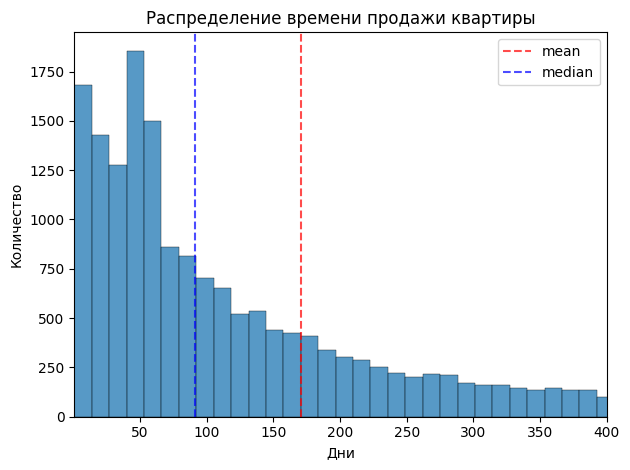

In [69]:
sns.histplot(data['days_exposition']).set(xlim=(1, 400))

mean = data['days_exposition'].mean()
median = data['days_exposition'].median()

plt.axvline(mean, color='red', linestyle='--', alpha=0.7, label='mean')
plt.axvline(median, color='blue', linestyle='--', alpha=0.7, label='median')
plt.legend()

plt.title('Распределение времени продажи квартиры')
plt.xlabel('Дни')
plt.ylabel('Количество')

plt.tight_layout()

In [70]:
print('Среднее:', round(mean))
print('Медиана:', round(median))

Среднее: 171
Медиана: 91


Средний промежуток времени, в течение которого осуществляется продажа квартиры, составляет 171 день. Медианный срок - 91 день. Поскольку среднее значение значительно превышает медиану, распределение имеет длинный правый хвост. Это означает, что небольшое количество квартир продаётся очень долго и смещает среднее значение вверх.

Например, максимальное число дней размещения объявления равно 1580 дням или 4.3 годам. Возможно, в таком случае человек просто забыл снять объявление с публикации, хотя по факту сделка была совершена.




### Что влияет на стоимость объекта

Исследуем, зависит ли цена от:
- общей площади;
- жилой площади;
- площади кухни;
- количества комнат;
- этажа, на котором расположена квартира (первый, последний, другой);
- даты размещения (день недели, месяц, год).

In [71]:
data['floor_type_int'] = data['floor_type'].map(lambda x: 1 if x == 'первый' else 2 if x == 'другой' else 3)

In [72]:
cols = ['last_price', 'total_area', 'living_area', 'kitchen_area', 'rooms', 'floor_type_int', 'weekday_exposition', 'month_exposition', 'year_exposition']

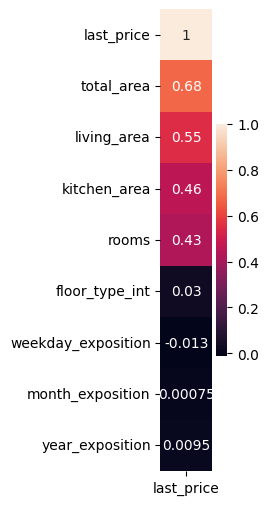

In [73]:
corr_m = data[cols].corr()[['last_price']]

plt.figure(figsize = (1,6))
sns.heatmap(corr_m, square = True, annot = True)
plt.show()

Наибольшая корреляция с ценой наблюдается у общей площади (0,68).
Жилая площадь и площадь кухни также демонстрируют положительную связь с ценой.

#### Зависимость от общей площади

In [74]:
price_data = data.groupby('total_area')['last_price'].median().reset_index()
price_data

,total_area,last_price
0,12,"2,400,000"
1,13,"1,850,000"
2,13,"1,686,000"
3,14,"1,190,000"
4,15,"1,725,000"
...,...,...
1554,114,"8,990,000"
1555,114,"8,700,000"
1556,114,"10,000,000"
1557,114,"6,500,000"


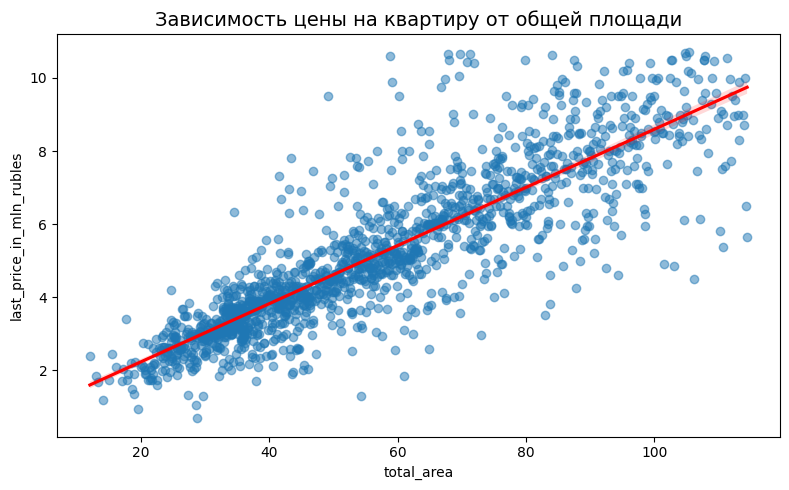

In [75]:
plt.figure(figsize=(8, 5))

sns.regplot(data=price_data, x='total_area', y=price_data['last_price'] / 1000000,
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})

plt.xlabel('total_area')
plt.ylabel('last_price_in_mln_rubles')
plt.title('Зависимость цены на квартиру от общей площади', fontsize=14)

plt.tight_layout()
plt.show()

Наблюдается зависимость, чем больше общая площадь квартиры, тем выше ее цена. 

#### Зависимость от жилой площади и площади кухни

In [76]:
living_area_data = data.groupby('living_area')['last_price'].median().reset_index()
living_area_data

,living_area,last_price
0,2,"4,340,000"
1,3,"4,440,000"
2,5,"2,680,000"
3,5,"6,100,000"
4,6,"3,799,000"
...,...,...
1280,84,"9,300,000"
1281,85,"4,940,790"
1282,87,"8,950,000"
1283,90,"10,150,000"


In [77]:
kitchen_area_data = data.groupby('kitchen_area')['last_price'].median().reset_index()
kitchen_area_data

,kitchen_area,last_price
0,1,"4,250,000"
1,2,"2,720,000"
2,2,"2,940,000"
3,2,"2,200,000"
4,3,"5,967,734"
...,...,...
748,41,"7,100,000"
749,41,"9,700,000"
750,43,"3,000,000"
751,48,"9,500,000"


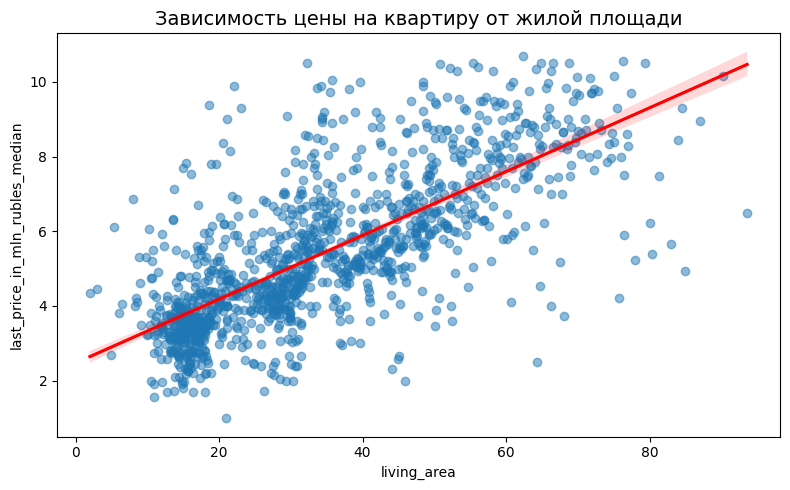

In [78]:
plt.figure(figsize=(8, 5))
sns.regplot(data=living_area_data, x='living_area', y=living_area_data['last_price'] / 1000000,
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})

plt.xlabel('living_area')
plt.ylabel('last_price_in_mln_rubles_median')
plt.title('Зависимость цены на квартиру от жилой площади', fontsize=14)

plt.tight_layout()

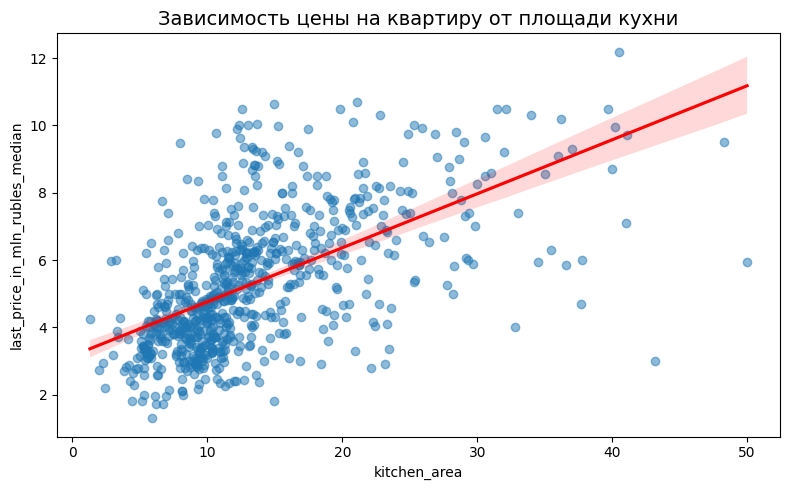

In [79]:
plt.figure(figsize=(8, 5))

sns.regplot(data=kitchen_area_data, x='kitchen_area', y=kitchen_area_data['last_price'] / 1000000,
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})

plt.xlabel('kitchen_area')
plt.ylabel('last_price_in_mln_rubles_median')
plt.title('Зависимость цены на квартиру от площади кухни', fontsize=14)

plt.tight_layout()

Также, наблюдается зависимость, чем выше площадь кухни или жилая, тем выше стоимость жилья. 

#### Зависимость от количества комнат

In [80]:
rooms_data = data.groupby('rooms')['last_price'].median().reset_index()
rooms_data

,rooms,last_price
0,1,"3,560,000"
1,2,"4,600,000"
2,3,"5,600,000"
3,4,"6,500,000"
4,5,"7,580,000"
5,6,"7,982,000"


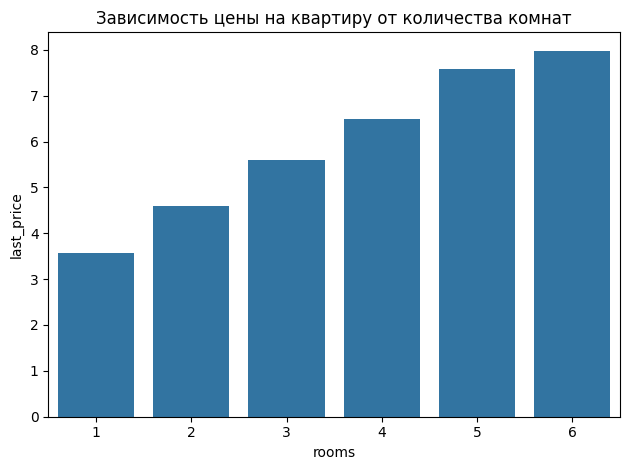

In [81]:
sns.barplot(x=rooms_data['rooms'], y=rooms_data['last_price']/1000000)

plt.title('Зависимость цены на квартиру от количества комнат')
plt.tight_layout()

Чем больше комнат, тем больше цена на квартиру. Скорее всего это связано также с общей площадью квартиры.

#### Зависимость от типа этажа

In [82]:
floors_data = data.groupby('floor_type')['last_price'].median().reset_index()
floors_data

,floor_type,last_price
0,другой,"4,500,000"
1,первый,"3,800,000"
2,последний,"3,999,000"


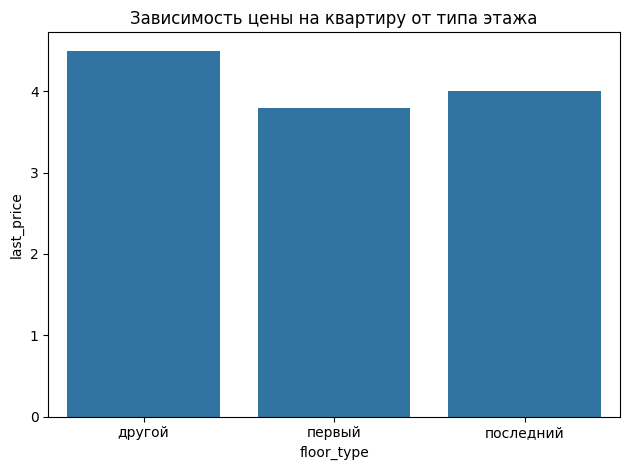

In [83]:
sns.barplot(x=floors_data['floor_type'], y=floors_data['last_price']/1000000)

plt.title('Зависимость цены на квартиру от типа этажа')
plt.tight_layout()

Квартиры на первом и последнем этажах в среднем дешевле квартир, расположенных на промежуточных этажах.

#### Зависимость от дня, месяца и года размещения

In [84]:
weekday_data = data.groupby('weekday_exposition')['last_price'].median().reset_index()
month_data = data.groupby('month_exposition')['last_price'].median().reset_index()
year_data = data.groupby('year_exposition')['last_price'].median().reset_index()

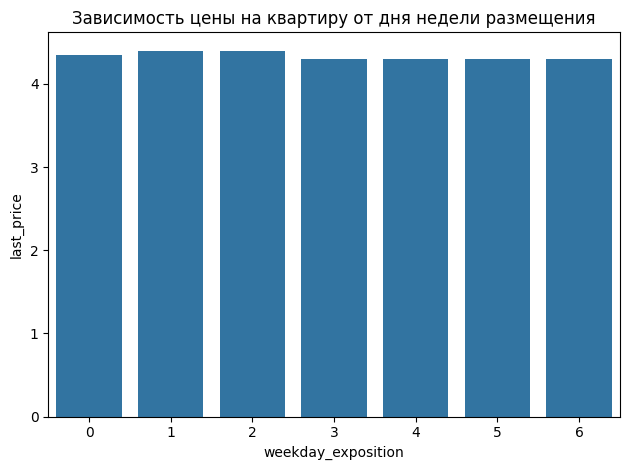

In [85]:
sns.barplot(x=weekday_data['weekday_exposition'], y=weekday_data['last_price']/1000000)

plt.title('Зависимость цены на квартиру от дня недели размещения')
plt.tight_layout()

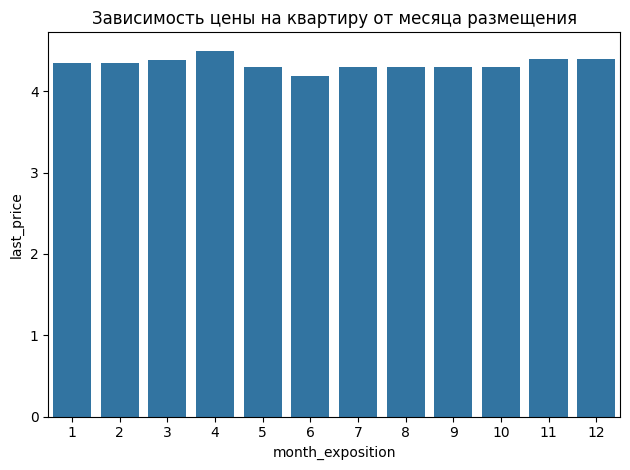

In [86]:
sns.barplot(x=month_data['month_exposition'], y=month_data['last_price']/1000000)

plt.title('Зависимость цены на квартиру от месяца размещения')
plt.tight_layout()

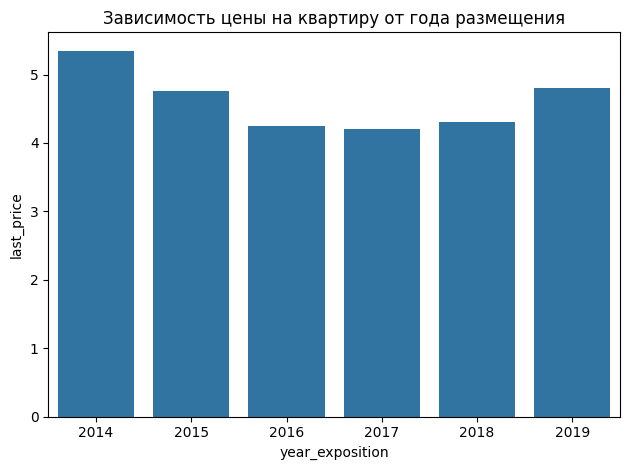

In [87]:
sns.barplot(x=year_data['year_exposition'], y=year_data['last_price']/1000000)

plt.title('Зависимость цены на квартиру от года размещения')
plt.tight_layout()

Существенной зависимости цены от дня недели и месяца публикации не наблюдается.

Влияние года размещения заметно сильнее и связано с изменением рыночной ситуации.

### Населенные пункты

In [88]:
top_locations = data['locality_name_clean'].value_counts()[:10].index

In [89]:
top_locations_price_data = data.loc[data['locality_name_clean'].isin(top_locations)] \
                               .pivot_table(index='locality_name_clean', 
                                            values='price_m2',
                                            aggfunc=['median', 'count']).reset_index()

top_locations_price_data.columns = ['locality_name_clean', 'median_price_m2', 'cnt_for_sale']
top_locations_price_data = top_locations_price_data.sort_values(by='median_price_m2', ascending=False)

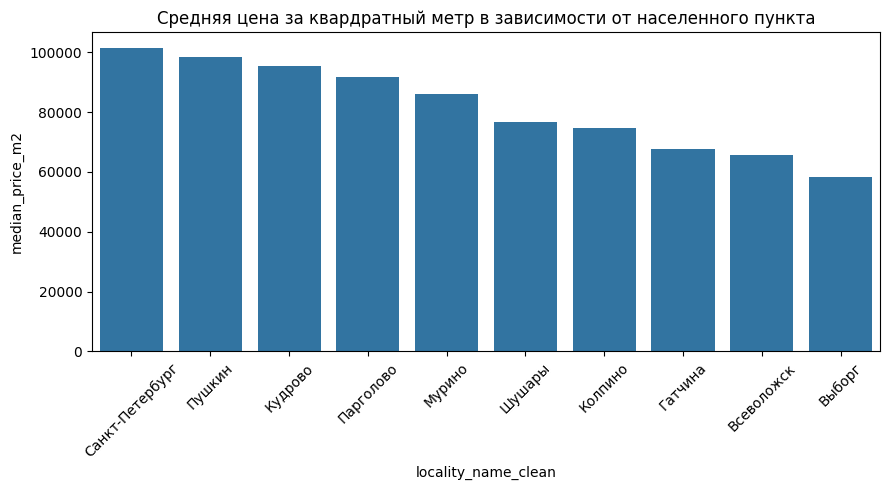

In [90]:
plt.figure(figsize=(9, 5))

sns.barplot(x=top_locations_price_data['locality_name_clean'], y=top_locations_price_data['median_price_m2'])

plt.xticks(rotation=45)
plt.title('Средняя цена за квардратный метр в зависимости от населенного пункта')
plt.tight_layout()

Населённые пункты с самой высокой и низкой стоимостью квадратного метра - Санкт-Петербург и Выборг, соответственно. 

### Удаленность от центра города в Санкт-Петербурге

In [91]:
spb_pivot = data.loc[data['locality_name_clean'] == 'Санкт-Петербург'] \
                .pivot_table(index='cityCenters_nearest_km', values='last_price', aggfunc='median')

spb_pivot.index = spb_pivot.index.astype(int)

spb_pivot

,last_price
cityCenters_nearest_km,
0,"7,200,000"
1,"7,985,000"
2,"7,850,000"
3,"6,950,000"
4,"7,100,000"
5,"7,200,000"
6,"6,695,000"
7,"6,200,000"
8,"6,067,020"


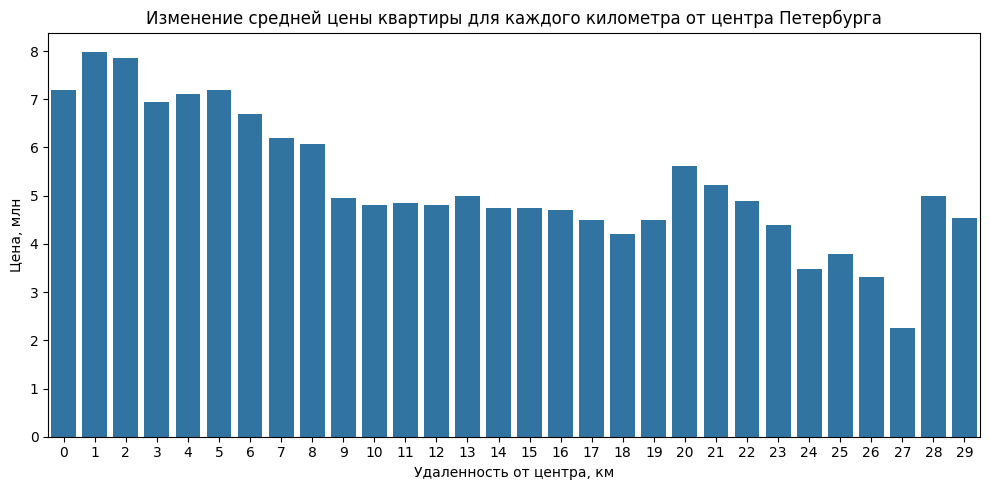

In [92]:
plt.figure(figsize=(10,5))

sns.barplot(x=spb_pivot.index, y=spb_pivot['last_price']/1000000)

plt.title('Изменение средней цены квартиры для каждого километра от центра Петербурга')
plt.xlabel('Удаленность от центра, км')
plt.ylabel('Цена, млн')

plt.tight_layout()

Квартиры в самом центре Санкт-Петербурга вплоть до 8 км от него в среднем стоят дороже. 

## Итоговые выводы

Перед проведением анализа были обработаны пропуски, устранены неявные дубликаты в названиях населённых пунктов, скорректированы аномальные значения и созданы дополнительные признаки для анализа стоимости недвижимости.

* Наибольшее влияние на стоимость квартиры оказывает её площадь;
* Квартиры на первом и последнем этажах в среднем стоят дешевле квартир на промежуточных этажах;
* Стоимость квадратного метра существенно различается между населёнными пунктами;
* Цена недвижимости снижается по мере удаления от центра Санкт-Петербурга;
* Большинство квартир продаётся в течение нескольких месяцев после публикации объявления.